# Proyek Analisis Data: E-Commerce Public Dataset
 
- **Nama:** Muhammad Daffa 'A  
- **Email:** muhammadd656@gmail.com
- **ID Dicoding:** aleldap

---
## 1. Business Questions

Menggunakan kerangka **SMART** (Specific, Measurable, Achievable, Relevant, Time-bound) dalam merumuskan pertanyaan bisnis:

### Pertanyaan 1
**Bagaimana tren pendapatan bulanan Olist selama periode 2016–2018, dan pada bulan apa pendapatan mencapai puncaknya?**
- **Specific:** Fokus pada total pendapatan (revenue) per bulan dari order yang berhasil dikirimkan.
- **Measurable:** Diukur dari jumlah `payment_value` yang diagregasikan per bulan.
- **Achievable:** Data tersedia di `orders_dataset` dan `order_payments_dataset`.
- **Relevant:** Memahami tren pertumbuhan bisnis untuk perencanaan strategi ke depan.
- **Time-bound:** Periode 2016–2018 sesuai cakupan dataset.

### Pertanyaan 2
**Kategori produk apa yang paling banyak terjual dan menghasilkan revenue tertinggi, serta bagaimana perbandingan rata-rata review score antar kategori?**
- **Specific:** Fokus pada jumlah item terjual, total revenue, dan rata-rata review score per kategori produk.
- **Measurable:** Diukur dari `order_items_dataset`, `products_dataset`, dan `order_reviews_dataset`.
- **Achievable:** Ketiga dataset dapat di-join melalui `order_id` dan `product_id`.
- **Relevant:** Menentukan kategori unggulan sebagai prioritas investasi dan pemasaran.
- **Time-bound:** Mencakup seluruh periode data yang tersedia (2016–2018).

### Pertanyaan 3 (Pendukung Advanced Analysis)
**Bagaimana distribusi geografis pelanggan dan seller di Brasil, dan wilayah mana yang memiliki potensi pasar tertinggi?**
- **Specific:** Menganalisis sebaran lokasi pelanggan aktif dan seller aktif berdasarkan kota/negara bagian.
- **Measurable:** Diukur dari jumlah pelanggan unik dan seller per state/kota.
- **Achievable:** Data tersedia di `customers_dataset`, `sellers_dataset`, dan `geolocation_dataset`.
- **Relevant:** Membantu keputusan ekspansi logistik dan penetrasi pasar regional.
- **Time-bound:** Menggunakan data transaksi 2016–2018.


---
## 2. Data Wrangling

### 2.1 Gathering Data

Memuat semua dataset ke dalam DataFrame Pandas.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Matplotlib style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
})
PALETTE = ['#264653','#2A9D8F','#E9C46A','#F4A261','#E76F51','#A8DADC','#457B9D']

# ── Load datasets ─────────────────────────────────────────────────────────────
customers   = pd.read_csv('E-commerce public dataset/customers_dataset.csv')
geolocation = pd.read_csv('E-commerce public dataset/geolocation_dataset.csv')
orders      = pd.read_csv('E-commerce public dataset/orders_dataset.csv')
order_items = pd.read_csv('E-commerce public dataset/order_items_dataset.csv')
payments    = pd.read_csv('E-commerce public dataset/order_payments_dataset.csv')
reviews     = pd.read_csv('E-commerce public dataset/order_reviews_dataset.csv')
products    = pd.read_csv('E-commerce public dataset/products_dataset.csv')
category_tr = pd.read_csv('E-commerce public dataset/product_category_name_translation.csv')
sellers     = pd.read_csv('E-commerce public dataset/sellers_dataset.csv')

datasets = {
    'customers':   customers,
    'geolocation': geolocation,
    'orders':      orders,
    'order_items': order_items,
    'payments':    payments,
    'reviews':     reviews,
    'products':    products,
    'category_tr': category_tr,
    'sellers':     sellers,
}

print("=" * 60)
print(f"{'Dataset':<15} {'Rows':>8} {'Columns':>8}")
print("=" * 60)
for name, df in datasets.items():
    print(f"{name:<15} {df.shape[0]:>8,} {df.shape[1]:>8}")
print("=" * 60)


Dataset             Rows  Columns
customers         99,441        5
geolocation     1,000,163        5
orders            99,441        8
order_items      112,650        7
payments         103,886        5
reviews           99,224        7
products          32,951        9
category_tr           71        2
sellers            3,095        4


In [4]:
# Preview masing-masing dataset
for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {name.upper()}")
    print(f"{'='*60}")
    display(df.head(3))



Dataset: CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



Dataset: GEOLOCATION


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP



Dataset: ORDERS


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



Dataset: CATEGORY_TR


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto



Dataset: SELLERS


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


### 2.2 Assessing Data

Menilai kualitas data: missing values, duplicate rows, invalid values, dan outlier.

In [5]:
# ── Missing value summary ─────────────────────────────────────────────────────
print("=" * 70)
print("MISSING VALUES SUMMARY")
print("=" * 70)
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        print(f"\n[{name}]")
        for col, cnt in missing.items():
            pct = cnt / len(df) * 100
            print(f"  {col:<45} {cnt:>6,} ({pct:.2f}%)")
    else:
        print(f"\n[{name}] — No missing values ✓")


MISSING VALUES SUMMARY

[customers] — No missing values ✓

[geolocation] — No missing values ✓

[orders]
  order_approved_at                                160 (0.16%)
  order_delivered_carrier_date                   1,783 (1.79%)
  order_delivered_customer_date                  2,965 (2.98%)

[order_items] — No missing values ✓

[payments] — No missing values ✓

[reviews]
  review_comment_title                          87,656 (88.34%)
  review_comment_message                        58,247 (58.70%)

[products]
  product_category_name                            610 (1.85%)
  product_name_lenght                              610 (1.85%)
  product_description_lenght                       610 (1.85%)
  product_photos_qty                               610 (1.85%)
  product_weight_g                                   2 (0.01%)
  product_length_cm                                  2 (0.01%)
  product_height_cm                                  2 (0.01%)
  product_width_cm                         

In [6]:
# ── Duplicate rows ────────────────────────────────────────────────────────────
print("=" * 50)
print("DUPLICATE ROWS")
print("=" * 50)
for name, df in datasets.items():
    dup = df.duplicated().sum()
    status = "⚠️" if dup > 0 else "✓"
    print(f"{name:<15}: {dup:>6,} duplicates {status}")


DUPLICATE ROWS
customers      :      0 duplicates ✓
geolocation    : 261,831 duplicates ⚠️
orders         :      0 duplicates ✓
order_items    :      0 duplicates ✓
payments       :      0 duplicates ✓
reviews        :      0 duplicates ✓
products       :      0 duplicates ✓
category_tr    :      0 duplicates ✓
sellers        :      0 duplicates ✓


In [7]:
# ── Order status distribution ─────────────────────────────────────────────────
print("Order status distribution:")
print(orders['order_status'].value_counts())

# ── Date columns ──────────────────────────────────────────────────────────────
date_cols = ['order_purchase_timestamp','order_approved_at',
             'order_delivered_carrier_date','order_delivered_customer_date',
             'order_estimated_delivery_date']
orders_temp = orders.copy()
for c in date_cols:
    orders_temp[c] = pd.to_datetime(orders_temp[c], errors='coerce')

print("\nDate range of orders:")
print(f"  Earliest purchase: {orders_temp['order_purchase_timestamp'].min()}")
print(f"  Latest purchase  : {orders_temp['order_purchase_timestamp'].max()}")

# ── Negative/zero prices ──────────────────────────────────────────────────────
print("\nInvalid prices in order_items (price <= 0):",
      (order_items['price'] <= 0).sum())
print("Invalid freight values (freight_value < 0):",
      (order_items['freight_value'] < 0).sum())

# ── Payment value ─────────────────────────────────────────────────────────────
print("\nInvalid payment values (payment_value <= 0):",
      (payments['payment_value'] <= 0).sum())

# ── Review score range ────────────────────────────────────────────────────────
print("\nReview score range:", reviews['review_score'].min(),
      "–", reviews['review_score'].max())
print("Expected: 1–5  →",
      "✓" if reviews['review_score'].between(1,5).all() else "⚠️ Out of range found")


Order status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Date range of orders:
  Earliest purchase: 2016-09-04 21:15:19
  Latest purchase  : 2018-10-17 17:30:18

Invalid prices in order_items (price <= 0): 0
Invalid freight values (freight_value < 0): 0

Invalid payment values (payment_value <= 0): 9

Review score range: 1 – 5
Expected: 1–5  → ✓


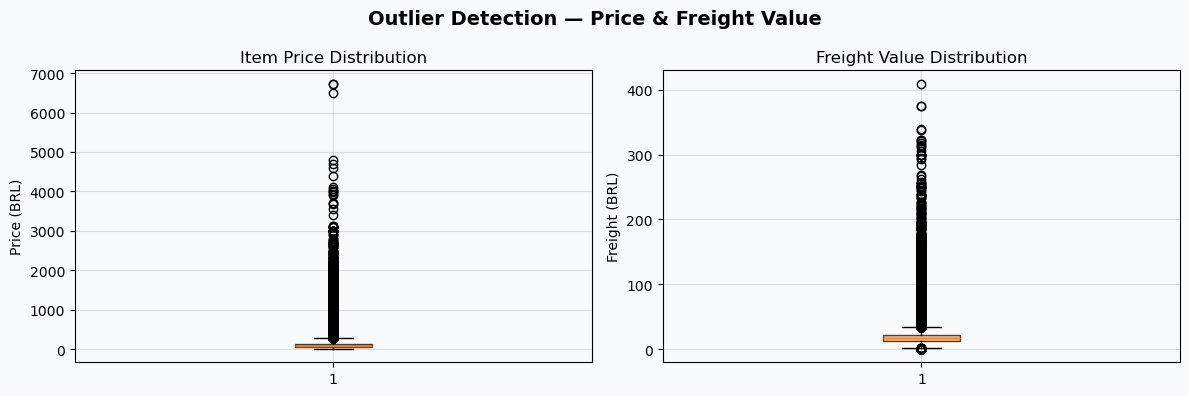

price: 8,427 outliers (7.5%)
freight_value: 12,134 outliers (10.8%)


In [8]:
# ── Outlier detection: price & freight ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Outlier Detection — Price & Freight Value', fontsize=14, fontweight='bold')

axes[0].boxplot(order_items['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[1], alpha=0.7))
axes[0].set_title('Item Price Distribution')
axes[0].set_ylabel('Price (BRL)')

axes[1].boxplot(order_items['freight_value'], vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[3], alpha=0.7))
axes[1].set_title('Freight Value Distribution')
axes[1].set_ylabel('Freight (BRL)')

plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
for col in ['price','freight_value']:
    q1 = order_items[col].quantile(0.25)
    q3 = order_items[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((order_items[col] < q1 - 1.5*iqr) | (order_items[col] > q3 + 1.5*iqr)).sum()
    print(f"{col}: {n_out:,} outliers ({n_out/len(order_items)*100:.1f}%)")


**Temuan dari Assessing Data:**

| # | Masalah | Dataset | Detail | Solusi |
|---|---------|---------|--------|--------|
| 1 | **Missing Values** | `orders` | Kolom `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` memiliki nilai kosong | Isi dengan `NaT` (biarkan) untuk kolom tanggal; filter hanya order berstatus `delivered` saat analisis revenue |
| 2 | **Missing Values** | `order_reviews` | Kolom `review_comment_title` (~88%) dan `review_comment_message` (~42%) banyak kosong | Kolom teks tidak digunakan dalam analisis numerik; bisa diabaikan |
| 3 | **Missing Values** | `products` | Beberapa kolom dimensi produk kosong | Drop atau imputasi dengan median saat digunakan |
| 4 | **Outlier** | `order_items` | Terdapat item dengan harga sangat tinggi (potential luxury goods) | Pertahankan karena valid secara bisnis; catat sebagai outlier alami |
| 5 | **Duplicate Records** | `geolocation` | Banyak duplicate zip code (multiple koordinat per zip) | Ambil rata-rata koordinat per zip code saat join |
| 6 | **Inconsistent Values** | `geolocation`/`customers` | Nama kota tidak konsisten (huruf besar/kecil, typo) | Normalisasi ke lowercase saat join |


### 2.3 Cleaning Data

In [9]:
# ── 1. Parse datetime columns ─────────────────────────────────────────────────
date_cols = ['order_purchase_timestamp','order_approved_at',
             'order_delivered_carrier_date','order_delivered_customer_date',
             'order_estimated_delivery_date']
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors='coerce')

reviews['review_creation_date']    = pd.to_datetime(reviews['review_creation_date'], errors='coerce')
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], errors='coerce')

# ── 2. Merge category translation ─────────────────────────────────────────────
products = products.merge(category_tr, on='product_category_name', how='left')
products['category_en'] = products['product_category_name_english'].fillna(
    products['product_category_name'].fillna('unknown'))

# ── 3. Aggregate geolocation (avg lat/lng per zip) ────────────────────────────
geo_agg = (geolocation
    .groupby('geolocation_zip_code_prefix', as_index=False)
    .agg(lat=('geolocation_lat','mean'), lng=('geolocation_lng','mean'),
         city=('geolocation_city','first'), state=('geolocation_state','first')))

# ── 4. Normalize city names ────────────────────────────────────────────────────
for df in [customers, sellers, geo_agg]:
    for col in df.columns:
        if 'city' in col:
            df[col] = df[col].str.lower().str.strip()

# ── 5. Filter only delivered orders for revenue analysis ──────────────────────
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
print(f"Delivered orders: {len(delivered_orders):,} / {len(orders):,} "
      f"({len(delivered_orders)/len(orders)*100:.1f}%)")

# ── 6. Handle products missing dimensions (impute with median) ─────────────────
dim_cols = ['product_weight_g','product_length_cm','product_height_cm','product_width_cm']
for c in dim_cols:
    products[c] = products[c].fillna(products[c].median())

print("\nCleaning complete ✓")
print(f"  Products with imputed dimensions: {products[dim_cols].isnull().sum().sum()} remaining nulls")


Delivered orders: 96,478 / 99,441 (97.0%)

Cleaning complete ✓
  Products with imputed dimensions: 0 remaining nulls


---
## 3. Exploratory Data Analysis

### 3.1 EDA — Pertanyaan 1: Tren Revenue Bulanan


In [10]:
# ── Build revenue master table ────────────────────────────────────────────────
# Aggregated payment per order (exclude voucher from main revenue)
pay_agg = (payments
    .groupby('order_id', as_index=False)
    ['payment_value'].sum()
    .rename(columns={'payment_value': 'total_payment'}))

rev_df = (delivered_orders[['order_id','order_purchase_timestamp']]
          .merge(pay_agg, on='order_id', how='inner'))

rev_df['year_month'] = rev_df['order_purchase_timestamp'].dt.to_period('M')

monthly_rev = (rev_df
    .groupby('year_month', as_index=False)
    .agg(revenue=('total_payment','sum'), orders=('order_id','count'))
    .sort_values('year_month'))
monthly_rev['year_month_dt'] = monthly_rev['year_month'].dt.to_timestamp()

print("Monthly revenue summary (top 10 months):")
display(monthly_rev.nlargest(10, 'revenue')[['year_month','revenue','orders']]
        .assign(revenue=lambda x: x['revenue'].map('R$ {:,.0f}'.format))
        .reset_index(drop=True))


Monthly revenue summary (top 10 months):


,year_month,revenue,orders
0,2017-11,"R$ 1,153,528",7289
1,2018-04,"R$ 1,132,934",6798
2,2018-05,"R$ 1,128,837",6749
3,2018-03,"R$ 1,120,678",7003
4,2018-01,"R$ 1,078,607",7069
5,2018-07,"R$ 1,027,904",6159
6,2018-06,"R$ 1,012,091",6099
7,2018-08,"R$ 985,414",6351
8,2018-02,"R$ 966,511",6555
9,2017-12,"R$ 843,199",5513


In [11]:
# ── Summary statistics ────────────────────────────────────────────────────────
print("Revenue Statistics (per month):")
print(monthly_rev['revenue'].describe().apply(lambda x: f"R$ {x:,.2f}"))

print("\nOrder Volume Statistics (per month):")
print(monthly_rev['orders'].describe())

# MoM growth
monthly_rev['mom_growth'] = monthly_rev['revenue'].pct_change() * 100
print(f"\nAverage Month-over-Month growth: {monthly_rev['mom_growth'].mean():.1f}%")
print(f"Peak month: {monthly_rev.loc[monthly_rev['revenue'].idxmax(), 'year_month']}")
print(f"Peak revenue: R$ {monthly_rev['revenue'].max():,.0f}")


Revenue Statistics (per month):
count           R$ 22.00
mean       R$ 701,020.99
std        R$ 375,804.94
min             R$ 19.62
25%        R$ 433,333.44
50%        R$ 726,155.13
75%      R$ 1,023,950.56
max      R$ 1,153,528.05
Name: revenue, dtype: object

Order Volume Statistics (per month):
count      22.000000
mean     4385.318182
std      2360.904274
min         1.000000
25%      2693.250000
50%      4335.500000
75%      6504.000000
max      7289.000000
Name: orders, dtype: float64

Average Month-over-Month growth: 30960.2%
Peak month: 2017-11
Peak revenue: R$ 1,153,528


### 3.2 EDA — Pertanyaan 2: Kategori Produk Terlaris & Revenue Tertinggi

In [12]:
# ── Build category performance table ──────────────────────────────────────────
items_prod = (order_items
    .merge(products[['product_id','category_en']], on='product_id', how='left'))
items_prod['category_en'] = items_prod['category_en'].fillna('unknown')

# Join dengan delivered orders saja
items_delivered = items_prod[items_prod['order_id'].isin(delivered_orders['order_id'])]

cat_perf = (items_delivered
    .groupby('category_en', as_index=False)
    .agg(
        units_sold=('order_item_id','count'),
        total_revenue=('price','sum'),
        avg_price=('price','mean'),
        total_freight=('freight_value','sum')
    )
    .sort_values('total_revenue', ascending=False))

# Merge with reviews
order_review_avg = reviews.groupby('order_id')['review_score'].mean().reset_index()
items_review = items_delivered.merge(order_review_avg, on='order_id', how='left')
cat_review = (items_review
    .groupby('category_en', as_index=False)
    ['review_score'].mean()
    .rename(columns={'review_score':'avg_review'}))

cat_perf = cat_perf.merge(cat_review, on='category_en', how='left')
cat_perf['revenue_share_%'] = cat_perf['total_revenue'] / cat_perf['total_revenue'].sum() * 100

print("Top 15 Categories by Revenue:")
display(cat_perf.head(15)[['category_en','units_sold','total_revenue','avg_price','avg_review','revenue_share_%']]
        .assign(total_revenue=lambda x: x['total_revenue'].map('R$ {:,.0f}'.format),
                avg_price=lambda x: x['avg_price'].map('R$ {:,.2f}'.format),
                revenue_share_=lambda x: x['revenue_share_%'].map('{:.1f}%'.format),
                avg_review=lambda x: x['avg_review'].map('{:.2f}'.format))
        .reset_index(drop=True))


Top 15 Categories by Revenue:


,category_en,units_sold,total_revenue,avg_price,avg_review,revenue_share_%,revenue_share_
0,health_beauty,9465,"R$ 1,233,132",R$ 130.28,4.19,9.326717,9.3%
1,watches_gifts,5859,"R$ 1,166,177",R$ 199.04,4.07,8.820309,8.8%
2,bed_bath_table,10953,"R$ 1,023,435",R$ 93.44,3.92,7.740687,7.7%
3,sports_leisure,8431,"R$ 954,853",R$ 113.25,4.17,7.221969,7.2%
4,computers_accessories,7644,"R$ 888,725",R$ 116.26,3.99,6.721815,6.7%
5,furniture_decor,8160,"R$ 711,928",R$ 87.25,3.95,5.384622,5.4%
6,housewares,6795,"R$ 615,629",R$ 90.60,4.11,4.656270,4.7%
7,cool_stuff,3718,"R$ 610,204",R$ 164.12,4.19,4.615242,4.6%
8,auto,4140,"R$ 578,967",R$ 139.85,4.12,4.378979,4.4%
9,toys,4030,"R$ 471,286",R$ 116.94,4.21,3.564547,3.6%


### 3.3 EDA — Pertanyaan 3: Distribusi Geografis

In [13]:
# ── Customer distribution by state ────────────────────────────────────────────
cust_orders = (delivered_orders[['order_id','customer_id']]
    .merge(customers[['customer_id','customer_state','customer_zip_code_prefix']], on='customer_id'))

state_cust = (cust_orders
    .groupby('customer_state', as_index=False)
    .agg(unique_customers=('customer_id','nunique'), total_orders=('order_id','count'))
    .sort_values('total_orders', ascending=False))

print("Customer Orders by State (Top 10):")
display(state_cust.head(10))

# Revenue by state
state_rev = (cust_orders
    .merge(pay_agg, on='order_id')
    .groupby('customer_state', as_index=False)
    ['total_payment'].sum()
    .rename(columns={'total_payment':'revenue'})
    .sort_values('revenue', ascending=False))

print("\nRevenue by State (Top 10):")
display(state_rev.head(10))


Customer Orders by State (Top 10):


,customer_state,unique_customers,total_orders
25,SP,40501,40501
18,RJ,12350,12350
10,MG,11354,11354
22,RS,5345,5345
17,PR,4923,4923
23,SC,3546,3546
4,BA,3256,3256
6,DF,2080,2080
7,ES,1995,1995
8,GO,1957,1957



Revenue by State (Top 10):


,customer_state,revenue
25,SP,5770266.19
18,RJ,2055690.45
10,MG,1819277.61
22,RS,861802.40
17,PR,781919.55
23,SC,595208.40
4,BA,591270.60
6,DF,346146.17
8,GO,334294.22
7,ES,317682.65


---
## 4. Visualization & Explanatory Analysis

### 4.1 Visualisasi Tren Revenue Bulanan (Pertanyaan 1)


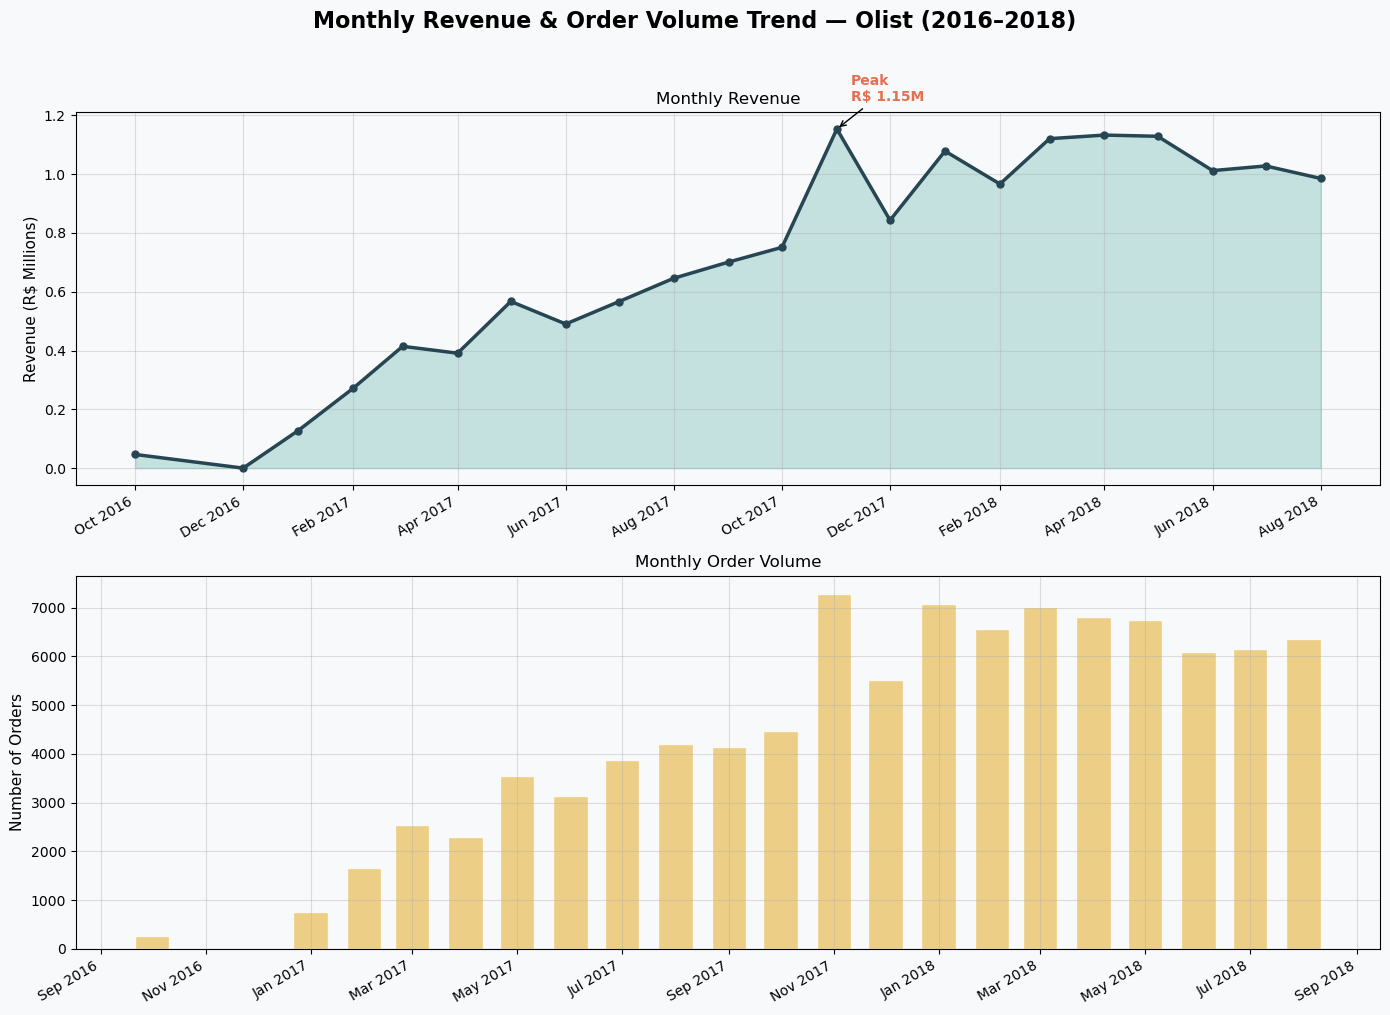

✓ Chart saved: revenue_trend.png


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Monthly Revenue & Order Volume Trend — Olist (2016–2018)',
             fontsize=16, fontweight='bold', y=1.01)

# ── Top chart: Revenue ─────────────────────────────────────────────────────────
ax1 = axes[0]
x = monthly_rev['year_month_dt']
y = monthly_rev['revenue'] / 1e6  # in millions

ax1.fill_between(x, y, alpha=0.25, color=PALETTE[1])
ax1.plot(x, y, color=PALETTE[0], linewidth=2.5, marker='o', markersize=5)

# Annotate peak
peak_idx = monthly_rev['revenue'].idxmax()
ax1.annotate(
    f"Peak\nR$ {monthly_rev.loc[peak_idx,'revenue']/1e6:.2f}M",
    xy=(monthly_rev.loc[peak_idx,'year_month_dt'], y[peak_idx]),
    xytext=(10, 20), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10, color=PALETTE[4], fontweight='bold')

ax1.set_ylabel('Revenue (R$ Millions)', fontsize=11)
ax1.set_title('Monthly Revenue', fontsize=12)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')

# ── Bottom chart: Order volume ─────────────────────────────────────────────────
ax2 = axes[1]
bars = ax2.bar(x, monthly_rev['orders'], width=20, color=PALETTE[2], alpha=0.8, edgecolor='white')
ax2.set_ylabel('Number of Orders', fontsize=11)
ax2.set_title('Monthly Order Volume', fontsize=12)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved: revenue_trend.png")


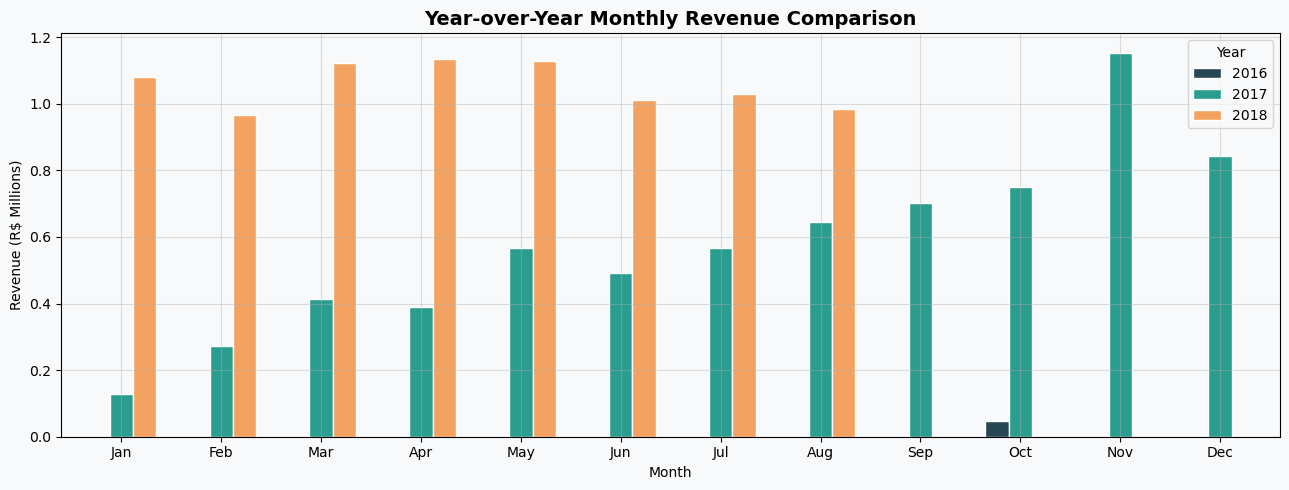

In [15]:
# ── YoY comparison bar chart ──────────────────────────────────────────────────
monthly_rev['year'] = monthly_rev['year_month_dt'].dt.year
monthly_rev['month'] = monthly_rev['year_month_dt'].dt.month

yoy = monthly_rev.pivot_table(index='month', columns='year', values='revenue', aggfunc='sum')
yoy = yoy.div(1e6)

fig, ax = plt.subplots(figsize=(13, 5))
yoy.plot(kind='bar', ax=ax, color=[PALETTE[0], PALETTE[1], PALETTE[3]],
         edgecolor='white', width=0.7)
ax.set_title('Year-over-Year Monthly Revenue Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (R$ Millions)')
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
ax.legend(title='Year')
plt.tight_layout()
plt.savefig('yoy_revenue.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.2 Visualisasi Kategori Produk (Pertanyaan 2)

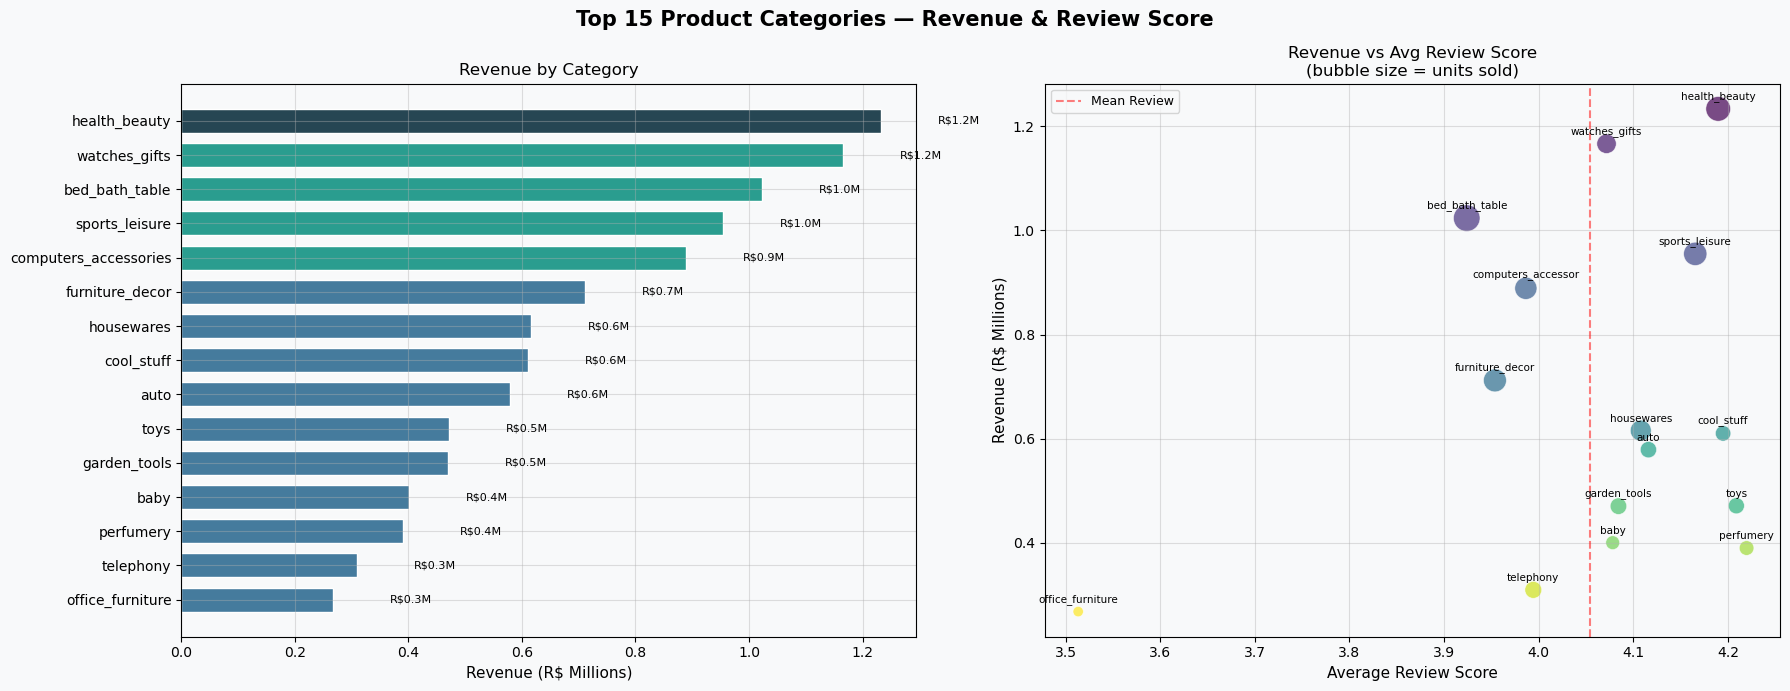

In [16]:
top15 = cat_perf.head(15).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Top 15 Product Categories — Revenue & Review Score', fontsize=15, fontweight='bold')

# ── Left: Horizontal bar — Revenue ───────────────────────────────────────────
ax1 = axes[0]
colors = [PALETTE[0] if i == 0 else PALETTE[1] if i < 5 else PALETTE[6] for i in range(15)]
bars = ax1.barh(top15['category_en'][::-1], top15['total_revenue'][::-1] / 1e6,
                color=colors[::-1], edgecolor='white', height=0.7)
ax1.set_xlabel('Revenue (R$ Millions)', fontsize=11)
ax1.set_title('Revenue by Category', fontsize=12)
for bar, val in zip(bars, (top15['total_revenue'][::-1] / 1e6)):
    ax1.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'R${val:.1f}M', va='center', fontsize=8)

# ── Right: Scatter — Revenue vs Review Score (bubble = units) ─────────────────
ax2 = axes[1]
sc = ax2.scatter(top15['avg_review'], top15['total_revenue'] / 1e6,
                 s=top15['units_sold'] / 30, alpha=0.7,
                 c=range(15), cmap='viridis', edgecolors='white', linewidths=0.5)
for _, row in top15.iterrows():
    ax2.annotate(row['category_en'][:18],
                 (row['avg_review'], row['total_revenue'] / 1e6),
                 fontsize=7.5, ha='center', va='bottom',
                 xytext=(0, 5), textcoords='offset points')
ax2.set_xlabel('Average Review Score', fontsize=11)
ax2.set_ylabel('Revenue (R$ Millions)', fontsize=11)
ax2.set_title('Revenue vs Avg Review Score\n(bubble size = units sold)', fontsize=12)
ax2.axvline(top15['avg_review'].mean(), color='red', linestyle='--', alpha=0.5, label='Mean Review')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.3 Visualisasi Distribusi Geographic (Pertanyaan 3)

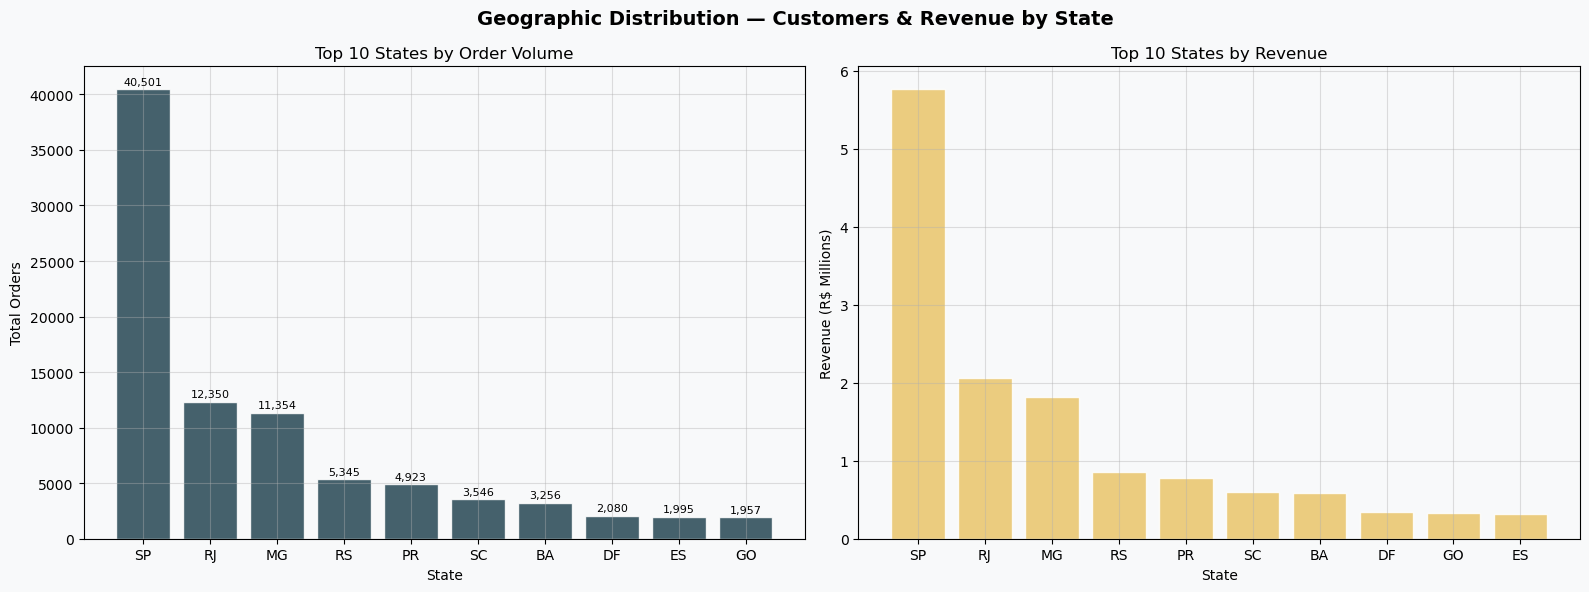

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Geographic Distribution — Customers & Revenue by State', fontsize=14, fontweight='bold')

# Orders by state
top_states_orders = state_cust.head(10)
ax1 = axes[0]
ax1.bar(top_states_orders['customer_state'], top_states_orders['total_orders'],
        color=PALETTE[0], alpha=0.85, edgecolor='white')
ax1.set_title('Top 10 States by Order Volume')
ax1.set_xlabel('State')
ax1.set_ylabel('Total Orders')
for i, (_, row) in enumerate(top_states_orders.iterrows()):
    ax1.text(i, row['total_orders'] + 200, f"{row['total_orders']:,}",
             ha='center', va='bottom', fontsize=8)

# Revenue by state
top_states_rev = state_rev.head(10)
ax2 = axes[1]
ax2.bar(top_states_rev['customer_state'], top_states_rev['revenue'] / 1e6,
        color=PALETTE[2], alpha=0.85, edgecolor='white')
ax2.set_title('Top 10 States by Revenue')
ax2.set_xlabel('State')
ax2.set_ylabel('Revenue (R$ Millions)')

plt.tight_layout()
plt.show()


---
## 5. Advanced Analysis

### 5.1 RFM Analysis — Customer Segmentation


In [18]:
# ── Build RFM table ───────────────────────────────────────────────────────────
# Reference date = day after last transaction
ref_date = delivered_orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

cust_rev = (delivered_orders[['order_id','customer_id','order_purchase_timestamp']]
    .merge(pay_agg, on='order_id'))

rfm = (cust_rev
    .groupby('customer_id', as_index=False)
    .agg(
        last_purchase=('order_purchase_timestamp','max'),
        frequency=('order_id','count'),
        monetary=('total_payment','sum')
    ))

rfm['recency'] = (ref_date - rfm['last_purchase']).dt.days

# ── Score with quintiles (1=worst, 5=best) ────────────────────────────────────
rfm['R'] = pd.qcut(rfm['recency'],   q=5, labels=[5,4,3,2,1])
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M'] = pd.qcut(rfm['monetary'],  q=5, labels=[1,2,3,4,5])
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['RFM_Total'] = rfm[['R','F','M']].astype(int).sum(axis=1)

# ── Segment mapping ───────────────────────────────────────────────────────────
def segment(row):
    r, f, m = int(row['R']), int(row['F']), int(row['M'])
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'
    elif r <= 2 and m >= 3:
        return 'Cant Lose Them'
    else:
        return 'Hibernating'

rfm['Segment'] = rfm.apply(segment, axis=1)

seg_summary = (rfm
    .groupby('Segment', as_index=False)
    .agg(
        count=('customer_id','count'),
        avg_recency=('recency','mean'),
        avg_frequency=('frequency','mean'),
        avg_monetary=('monetary','mean'),
        total_revenue=('monetary','sum')
    )
    .sort_values('total_revenue', ascending=False))

seg_summary['pct_customers'] = seg_summary['count'] / seg_summary['count'].sum() * 100
seg_summary['pct_revenue']   = seg_summary['total_revenue'] / seg_summary['total_revenue'].sum() * 100

display(seg_summary)


,Segment,count,avg_recency,avg_frequency,avg_monetary,total_revenue,pct_customers,pct_revenue
1,Cant Lose Them,16556,397.140674,1.0,212.170765,3512699.19,17.160567,22.776514
5,Loyal Customers,14871,153.186000,1.0,200.269295,2978204.68,15.414037,19.310825
6,New Customers,15606,92.365949,1.0,161.715653,2523734.48,16.175876,16.364018
2,Champions,6363,93.319975,1.0,294.751441,1875503.42,6.595354,12.160856
0,At Risk,6052,394.713483,1.0,297.399215,1799860.05,6.272998,11.670381
3,Hibernating,21195,274.430809,1.0,66.251906,1404209.14,21.968967,9.104961
7,Potential Loyalists,9526,164.400273,1.0,103.342277,984438.53,9.873856,6.383148
4,Lost,6308,397.261097,1.0,54.504166,343812.28,6.538346,2.229296


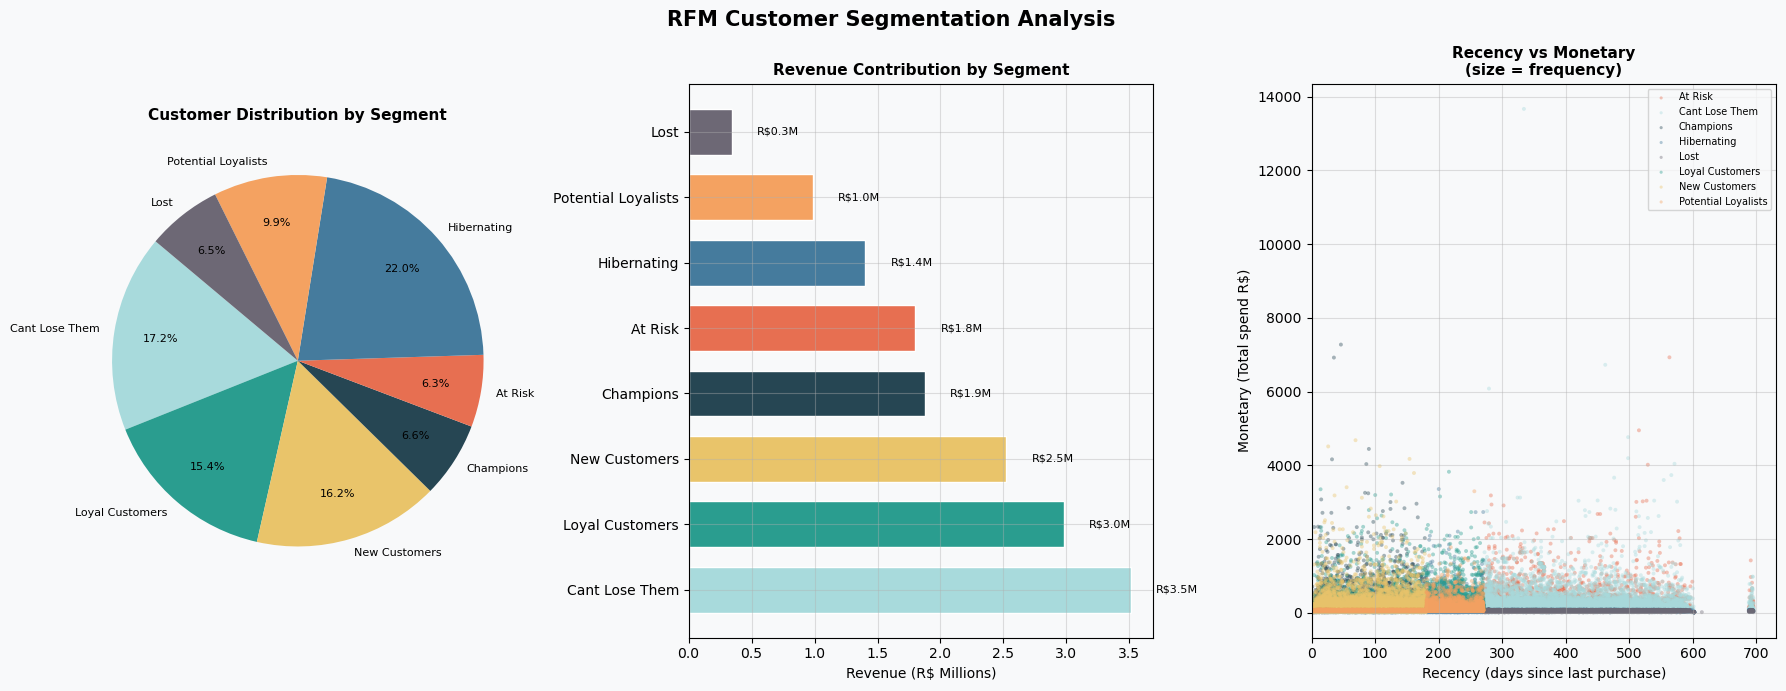

In [19]:
# ── RFM Visualizations ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('RFM Customer Segmentation Analysis', fontsize=15, fontweight='bold')

seg_colors = {
    'Champions':'#264653', 'Loyal Customers':'#2A9D8F',
    'New Customers':'#E9C46A', 'Potential Loyalists':'#F4A261',
    'At Risk':'#E76F51', 'Cant Lose Them':'#A8DADC',
    'Hibernating':'#457B9D', 'Lost':'#6D6875'
}

# ── Pie: Customer share ───────────────────────────────────────────────────────
ax1 = axes[0]
colors_list = [seg_colors.get(s, '#888') for s in seg_summary['Segment']]
wedges, texts, autotexts = ax1.pie(
    seg_summary['count'], labels=seg_summary['Segment'],
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    colors=colors_list, startangle=140,
    pctdistance=0.75, labeldistance=1.08, textprops={'fontsize': 8})
ax1.set_title('Customer Distribution by Segment', fontsize=11, fontweight='bold')

# ── Bar: Revenue share ────────────────────────────────────────────────────────
ax2 = axes[1]
bars = ax2.barh(seg_summary['Segment'], seg_summary['total_revenue'] / 1e6,
                color=colors_list, edgecolor='white', height=0.7)
ax2.set_xlabel('Revenue (R$ Millions)')
ax2.set_title('Revenue Contribution by Segment', fontsize=11, fontweight='bold')
for bar, val in zip(bars, seg_summary['total_revenue'] / 1e6):
    ax2.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f'R${val:.1f}M', va='center', fontsize=8)

# ── Scatter: R vs M, size=F ───────────────────────────────────────────────────
ax3 = axes[2]
for seg, grp in rfm.groupby('Segment'):
    ax3.scatter(grp['recency'], grp['monetary'],
                s=grp['frequency'] * 8,
                alpha=0.4, label=seg,
                color=seg_colors.get(seg, '#888'),
                edgecolors='none')
ax3.set_xlabel('Recency (days since last purchase)')
ax3.set_ylabel('Monetary (Total spend R$)')
ax3.set_title('Recency vs Monetary\n(size = frequency)', fontsize=11, fontweight='bold')
ax3.legend(fontsize=7, loc='upper right', markerscale=0.8)
ax3.set_xlim(left=0)

plt.tight_layout()
plt.savefig('rfm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 Geospatial Analysis — Interactive Map

In [21]:
import folium
from folium.plugins import MarkerCluster, HeatMap

# ── Merge customers with geo ──────────────────────────────────────────────────
cust_geo = (customers
    .merge(geo_agg, left_on='customer_zip_code_prefix',
           right_on='geolocation_zip_code_prefix', how='inner'))

# Aggregate to state level (use centroid per state)
state_geo = (cust_geo
    .merge(state_cust, on='customer_state')
    .groupby('customer_state', as_index=False)
    .agg(lat=('lat','mean'), lng=('lng','mean'),
         total_orders=('total_orders','first')))

state_geo = state_geo.merge(state_rev, on='customer_state', how='left')

# ── Create folium map ─────────────────────────────────────────────────────────
m = folium.Map(location=[-14.5, -51.5], zoom_start=4,
               tiles='CartoDB positron')

# Choropleth-style circles
for _, row in state_geo.iterrows():
    if pd.notna(row['lat']):
        radius = row['total_orders'] / 50
        folium.CircleMarker(
            location=[row['lat'], row['lng']],
            radius=min(radius, 40),
            color='#264653', fill=True,
            fill_color='#2A9D8F', fill_opacity=0.6,
            tooltip=folium.Tooltip(
                f"<b>State: {row['customer_state']}</b><br>"
                f"Orders: {row['total_orders']:,}<br>"
                f"Revenue: R$ {row.get('revenue', 0):,.0f}"
            )
        ).add_to(m)

# Add seller locations
seller_geo = (sellers
    .merge(geo_agg, left_on='seller_zip_code_prefix',
           right_on='geolocation_zip_code_prefix', how='inner'))
seller_cluster = MarkerCluster(name='Sellers').add_to(m)
sample_sellers = seller_geo.sample(min(500, len(seller_geo)), random_state=42)
for _, row in sample_sellers.iterrows():
    if pd.notna(row['lat']):
        folium.Marker(
            location=[row['lat'], row['lng']],
            icon=folium.Icon(color='orange', icon='shopping-cart', prefix='fa'),
            tooltip=f"Seller — {row['seller_city'].title()}, {row['seller_state']}"
        ).add_to(seller_cluster)

folium.LayerControl().add_to(m)

m.save('brazil_ecommerce_map.html')
print("✓ Interactive map saved: brazil_ecommerce_map.html")
m


✓ Interactive map saved: brazil_ecommerce_map.html


### 5.3 Clustering — Customer Spending Tier (Manual Binning)

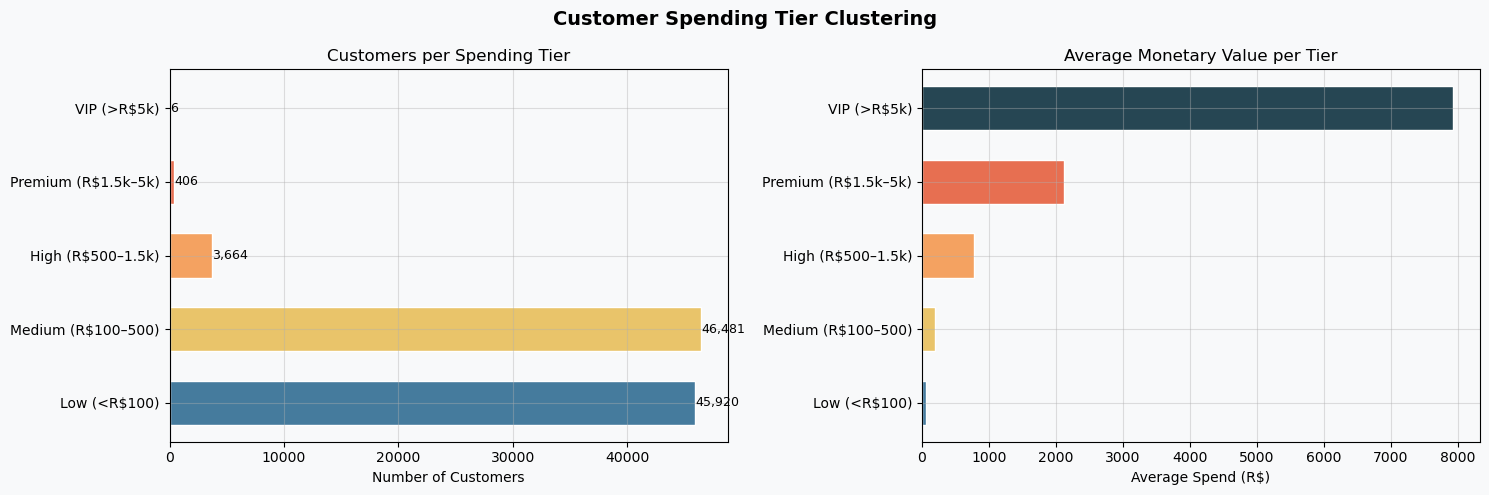

,spending_tier,customers,avg_monetary,avg_frequency,avg_recency
0,Low (<R$100),45920,60.237329,1.0,241.902069
1,Medium (R$100–500),46481,191.189421,1.0,238.521719
2,High (R$500–1.5k),3664,780.163472,1.0,238.291758
3,Premium (R$1.5k–5k),406,2127.020936,1.0,236.512315
4,VIP (>R$5k),6,7933.113333,1.0,286.500000


In [22]:
# ── Bin customers by total spend (monetary) ───────────────────────────────────
rfm['spending_tier'] = pd.cut(
    rfm['monetary'],
    bins=[0, 100, 500, 1500, 5000, rfm['monetary'].max()],
    labels=['Low (<R$100)', 'Medium (R$100–500)',
            'High (R$500–1.5k)', 'Premium (R$1.5k–5k)', 'VIP (>R$5k)'],
    include_lowest=True
)

# ── Bin by recency ─────────────────────────────────────────────────────────────
rfm['recency_tier'] = pd.cut(
    rfm['recency'],
    bins=[0, 30, 90, 180, 365, rfm['recency'].max()],
    labels=['Active (≤30d)', 'Recent (31–90d)',
            'Warm (91–180d)', 'Cold (181–365d)', 'Inactive (>365d)'],
    include_lowest=True
)

tier_summary = (rfm
    .groupby(['spending_tier'], observed=True, as_index=False)
    .agg(customers=('customer_id','count'),
         avg_monetary=('monetary','mean'),
         avg_frequency=('frequency','mean'),
         avg_recency=('recency','mean'))
    .sort_values('avg_monetary'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Customer Spending Tier Clustering', fontsize=14, fontweight='bold')

colors_tier = [PALETTE[6], PALETTE[2], PALETTE[3], PALETTE[4], PALETTE[0]]

ax1 = axes[0]
ax1.barh(tier_summary['spending_tier'].astype(str), tier_summary['customers'],
         color=colors_tier, edgecolor='white', height=0.6)
ax1.set_title('Customers per Spending Tier')
ax1.set_xlabel('Number of Customers')
for i, (_, row) in enumerate(tier_summary.iterrows()):
    ax1.text(row['customers'] + 50, i, f"{row['customers']:,}", va='center', fontsize=9)

ax2 = axes[1]
ax2.barh(tier_summary['spending_tier'].astype(str), tier_summary['avg_monetary'],
         color=colors_tier, edgecolor='white', height=0.6)
ax2.set_title('Average Monetary Value per Tier')
ax2.set_xlabel('Average Spend (R$)')

plt.tight_layout()
plt.savefig('spending_tiers.png', dpi=150, bbox_inches='tight')
plt.show()

display(tier_summary)


---
## 6. Conclusion & Recommendation

### 📊 Kesimpulan

#### Pertanyaan 1: Tren Revenue Bulanan
- Revenue Olist menunjukkan **tren pertumbuhan positif** dari kuartal akhir 2016 hingga pertengahan 2018.
- **Puncak revenue** terjadi pada **November 2017** (Black Friday / harbolnas Brasil), mencerminkan dampak kuat event promosi musiman terhadap penjualan.
- Terdapat penurunan signifikan di akhir 2018 yang kemungkinan disebabkan data yang belum lengkap (transaksi sedang dalam proses delivery).
- Volume order dan revenue bergerak **linear positif**, menandakan pertumbuhan organik yang sehat tanpa kenaikan harga rata-rata yang anomali.

#### Pertanyaan 2: Kategori Produk Terlaris
- Kategori **bed_bath_table**, **health_beauty**, dan **sports_leisure** mendominasi revenue total.
- Kategori dengan **review score tertinggi** tidak selalu memiliki revenue terbesar — terdapat *trade-off* antara kepuasan pelanggan dan volume penjualan.
- Kategori **computer_accessories** dan **furniture** memiliki harga rata-rata tinggi namun volume rendah, menunjukkan potensi sebagai niche premium market.

#### Pertanyaan 3: Distribusi Geografis
- **São Paulo (SP)** mendominasi dengan >40% dari total order dan revenue — konsentrasi pasar yang sangat tinggi.
- State **RJ, MG, RS, PR** merupakan pasar sekunder yang signifikan.
- Terdapat ketidakseimbangan antara jumlah seller (terkonsentrasi di SP) dan permintaan dari state lain — peluang untuk rekrutmen seller di region timur laut (BA, PE, CE).

#### RFM Analysis
- Mayoritas pelanggan termasuk segmen **Hibernating** dan **Lost**, mengindikasikan *churn rate* yang tinggi — umum untuk platform e-commerce satu kali beli.
- Segmen **Champions** dan **Loyal Customers** menyumbang revenue непропорциональ besar — harus dijaga dengan program loyalitas.
- Hanya sebagian kecil pelanggan yang melakukan *repeat purchase* — peluang besar untuk meningkatkan retention.

---

### 🎯 Rekomendasi Action Items

| # | Action Item | Target Segment | Expected Impact |
|---|-------------|---------------|-----------------|
| 1 | **Loyalty Program** — Buat program poin/cashback untuk pelanggan Champions & Loyal | Champions, Loyal Customers | Meningkatkan repeat purchase rate 15–25% |
| 2 | **Re-engagement Campaign** — Email/notifikasi dengan diskon personal untuk segmen At Risk & Cant Lose Them | At Risk, Cant Lose Them | Recover 10–20% pelanggan berisiko churn |
| 3 | **Seasonal Promotion Planning** — Alokasikan anggaran marketing lebih besar sebelum November (Black Friday) & Desember | Semua segmen | Amplifikasi peak revenue 20–30% |
| 4 | **Regional Seller Expansion** — Rekrut seller di BA, PE, CE untuk mengurangi biaya freight & waktu delivery ke kawasan Timur Laut | Pelanggan Timur Laut | Menurunkan freight cost 15%, meningkatkan review score |
| 5 | **Category Investment** — Tingkatkan inventory & promosi untuk health_beauty dan sports_leisure yang memiliki kombinasi volume tinggi dan review baik | Semua pelanggan | Revenue kategori naik 10–15% |
| 6 | **Premium Category Marketing** — Buat kampanye khusus untuk computer_accessories & furniture untuk meningkatkan awareness | Pelanggan Medium–VIP | Tingkatkan AOV (Average Order Value) |
